# Analiza Danych Obrazowych i Multimedialnych
## 🤖 Transformery

---

> ### **Zespół projektowy:**
> * Jan Zubalewicz
> * Maciej Kuźmicki
> * Mateusz Kubita
> * Radek Szewczyk
>
> **Data oddania:** 26.05.2026

---

## 🤖 Architektura Transformer

### Do czego służy? 
Architektura Transformer (wprowadzona w słynnej pracy *Attention Is All You Need*) służy do sekwencyjnego przetwarzania danych (np. tekstu, obrazu, audio) bez konieczności stosowania pętli rekurencyjnych (RNN, LSTM). W zadaniach przetwarzania języka naturalnego (NLP) – takich jak analiza zbioru IMDB – umożliwia precyzyjną klasyfikację tekstów, głębokie wychwytywanie kontekstu, analizę wydźwięku emocjonalnego (Sentiment Analysis) oraz generowanie treści z zachowaniem najwyższej dostępnej dokładności (State-of-the-Art).

### Na czym polega?
Głównym motorem tej metody jest **mechanizm uwagi (Self-Attention)**. Zamiast przetwarzać tekst słowo po słowie (jak starsze sieci), Transformer patrzy na całą sekwencję **jednocześnie** i matematycznie oblicza relację oraz siłę powiązania każdego słowa z pozostałymi w danym zdaniu.

Nasz eksperyment opiera się na architekturze **DistilBERT**, która realizuje ten proces w następujących krokach:
*   **Tokenizacja:** Przyjmuje tekst wejściowy rozbity na tokeny (mniejsze podfragmenty słów).
*   **Ekstrakcja kontekstu:** Przepuszcza tokeny przez warstwy uwagi, dynamicznie określając kontekst (np. słowo *"film"* w bliskim sąsiedztwie słowa *"genialny"* otrzymuje silną wagę reprezentującą pozytywny kontekst).
*   **Klasyfikacja końcowa:** Na samym końcu, przy użyciu nowo zainicjalizowanej głowy klasyfikatora (`classifier`), końcowy wektor kontekstowy jest mapowany na jedną z dwóch klas decyzyjnych: `0` (recenzja negatywna) lub `1` (recenzja pozytywna).

---

### 📚 Szczegółowe omówienia i źródła

*   **Artykuł Naukowy:** [Attention Is All You Need (arXiv)](https://arxiv.org/abs/1706.03762) – Oryginalna praca naukowa wprowadzająca architekturę Transformer.
*   **Wizualne Omówienie:** [The Illustrated Transformer - Jay Alammar](https://jalammar.github.io/illustrated-transformer/) – Najbardziej przystępny, graficzny przewodnik tłumaczący matematyczne podstawy modelu krok po kroku.
*   **Dokumentacja Modelu:** [Hugging Face DistilBERT Documentation](https://huggingface.co/docs/transformers/model_doc/distilbert) – Oficjalna specyfikacja techniczna wykorzystywanego przez nas wariantu modelu.

### 💻 Repozytoria Kodu i Tutoriale

*   **Główne Repozytorium:** [GitHub - huggingface/transformers](https://github.com/huggingface/transformers) – Oficjalne repozytorium frameworku, z którego pobieramy model oraz klasę `Trainer`.
*   **Oficjalny Tutorial:** [Hugging Face NLP Course - Text Classification](https://huggingface.co/learn/nlp-course/chapter3/1) – Praktyczny przewodnik po finetuningu modeli sekwencyjnych, na którym bazuje nasza pętla treningowa.

---

### Ignorowanie ostrzeżeń dla czytelności

In [1]:
import warnings
warnings.filterwarnings("ignore", message=".*pin_memory.*")
warnings.filterwarnings("ignore", message=".*IProgress not found*")
warnings.filterwarnings("ignore", message=".*HF_TOKEN*")
import os
import logging

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)


### Importy

In [2]:
import time
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

### Ładowanie danych

In [3]:
dataset = load_dataset("imdb").shuffle(seed=42).select_columns(["text", "label"])
train_data = dataset["train"].select(range(10000))
test_data = dataset["test"].select(range(500))

### Eksploracyjna analiza danych

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = train_data.to_pandas()

print("--- Pierwsze 3 wiersze ---")
print(df.head(3))
print("\n--- Informacje o zbiorze ---")
print(df.info())

--- Pierwsze 3 wiersze ---
                                                text  label
0  There is no relation at all between Fortier an...      1
1  This movie is a great. The plot is very true t...      1
2  George P. Cosmatos' "Rambo: First Blood Part I...      0

--- Informacje o zbiorze ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    10000 non-null  str  
 1   label   10000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 12.7 MB
None



--- Rozkład klas (0 = Negatywna, 1 = Pozytywna) ---
label
0    5004
1    4996
Name: count, dtype: int64


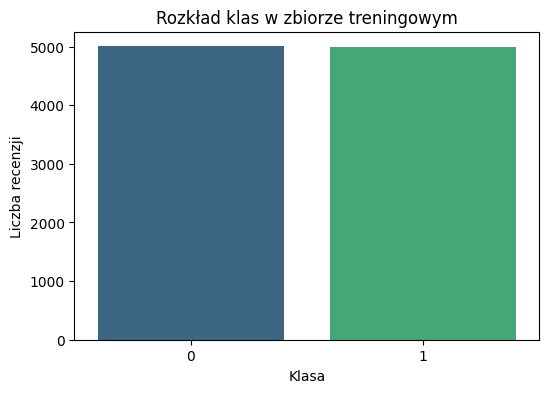

In [5]:
print("\n--- Rozkład klas (0 = Negatywna, 1 = Pozytywna) ---")
print(df["label"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label", hue="label", palette="viridis", legend=False)
plt.title("Rozkład klas w zbiorze treningowym")
plt.xlabel("Klasa")
plt.ylabel("Liczba recenzji")
plt.show()


--- Statystyki długości recenzji (w słowach) ---
count    10000.000000
mean       232.629000
std        172.041941
min         10.000000
25%        127.000000
50%        174.000000
75%        283.000000
max       1839.000000
Name: word_count, dtype: float64


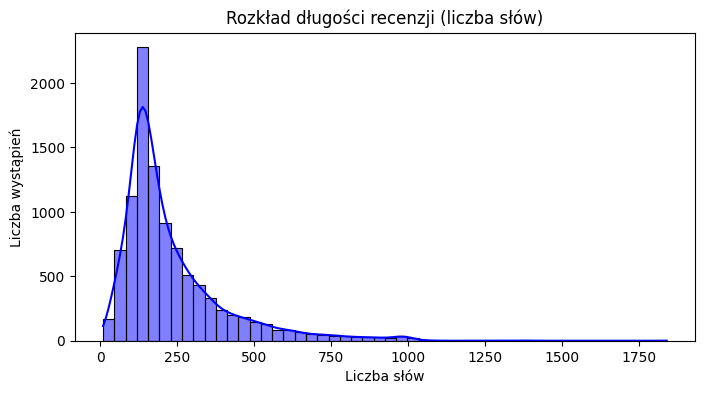

In [ ]:
# Analiza długości tekstu (liczba słów)
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

print("\n--- Statystyki długości recenzji (w słowach) ---")
print(df["word_count"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=50, kde=True, color="blue")
plt.title("Rozkład długości recenzji (liczba słów)")
plt.xlabel("Liczba słów")
plt.ylabel("Liczba wystąpień")
plt.show()

### Tokenizacja

In [7]:
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

tokenized_train = train_data.map(tokenize_function, batched=True)
tokenized_test = test_data.map(tokenize_function, batched=True)

## Eksperyment numer 1
### DistilBERT fine-tuning - ocena czy recenzja jest pozytywna, czy negatywna

In [ ]:
# wczytanie modelu
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

#przygotowanie metryk do ewaluacji
metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = metric_acc.compute(predictions=predictions, references=labels)
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="weighted")
    return {**acc, **f1}

# zdefiniowanie argumentów treningowych
training_args = TrainingArguments(
    output_dir="./results_1",
    eval_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_steps=5,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

# odpalenie treningu i zmierzenie czasu jego trwania
print("--- START TRENINGU ---")
start_time = time.time()
trainer.train()
end_time = time.time()
print(f"--- KONIEC: Czas uczenia: {end_time - start_time:.2f} s ---")

The following layers were not sharded: distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.attention.out_lin.bias, distilbert.transformer.layer.*.ffn.lin1.bias, pre_classifier.weight, distilbert.transformer.layer.*.attention.k_lin.weight, classifier.bias, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.embeddings.word_embeddings.weight, pre_classifier.bias, distilbert.embeddings.position_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.sa_layer_norm.

--- START TRENINGU ---


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.321478,0.406849,0.816000,0.816009
2,0.247625,0.507134,0.838000,0.837604
3,0.012412,0.734475,0.830000,0.830005


--- KONIEC: Czas uczenia: 191.88 s ---


### Ocena skuteczności

Generowanie macierzy pomyłek...


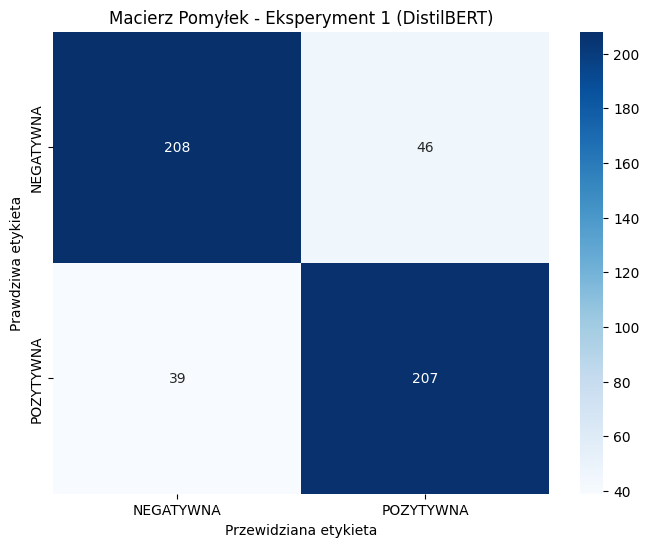

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
print("Generowanie macierzy pomyłek...")
predictions_output = trainer.predict(tokenized_test)
preds = np.argmax(predictions_output.predictions, axis=-1)
actuals = predictions_output.label_ids

cm = confusion_matrix(actuals, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['NEGATYWNA', 'POZYTYWNA'], 
            yticklabels=['NEGATYWNA', 'POZYTYWNA'])
plt.xlabel('Przewidziana etykieta')
plt.ylabel('Prawdziwa etykieta')
plt.title('Macierz Pomyłek - Eksperyment 1 (DistilBERT)')
plt.show()

In [10]:
import time
import torch
import torch.nn.functional as F

def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64).to(model.device)
    
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        outputs = model(**inputs)
    end_time = time.time()
    
    logits = outputs.logits
    probs = F.softmax(logits, dim=-1)
    
    confidence, predicted_class_id = torch.max(probs, dim=-1)
    latency = end_time - start_time
    
    labels = {0: "NEGATYWNA", 1: "POZYTYWNA"}
    result_label = labels[predicted_class_id.item()]
    conf_score = confidence.item() * 100
    
    return result_label, conf_score, latency

test_text = "This movie was a masterpiece, the acting was incredible!"
label, score, lat = predict_sentiment(test_text)

print("-" * 30)
print(f"TEKST: {test_text}")
print("-" * 30)
print(f"WERDYKT: {label}")
print(f"PEWNOŚĆ: {score:.2f}%")
print(f"OPÓŹNIENIE (Latency): {lat:.4f} s")
print("-" * 30)

------------------------------
TEKST: This movie was a masterpiece, the acting was incredible!
------------------------------
WERDYKT: POZYTYWNA
PEWNOŚĆ: 99.83%
OPÓŹNIENIE (Latency): 0.0598 s
------------------------------


## Eksperyment numer 2
### Analiza dlugosci sekwencji - badanie czasu treningu i jego skuteczności w zależności od długości sekwencji

In [11]:
dataset = load_dataset("imdb").shuffle(seed=42).select_columns(["text", "label"])

train_data = dataset["train"].select(range(10000))
test_data = dataset["test"].select(range(500))

In [ ]:
# 1. Definicja długości sekwencji do zbadania
sequence_lengths = [4, 16, 64, 128, 256]
results = {}
model_name = "distilbert-base-uncased"

# 2. Pętla eksperymentalna
for seq_len in sequence_lengths:
    print(f"\n" + "="*50)
    print(f"Rozpoczęcie prób dla maksymalnej długości sekwencji (n): {seq_len}")
    print("="*50)
    
    # Tokenizacja dostosowana do obecnej długości z pętli
    def tokenize_function(examples):
        return tokenizer(
            examples["text"], 
            padding="max_length", 
            truncation=True, 
            max_length=seq_len
        )

    tokenized_train = train_data.map(tokenize_function, batched=True)
    tokenized_test = test_data.map(tokenize_function, batched=True)

    # WAŻNE: Inicjujemy "świeży" model w każdej iteracji, aby poprzedni trening nie wpływał na wyniki kolejnego!
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    # zdefiniowanie argumentów treningowych
    training_args = TrainingArguments(
        output_dir=f"./results_seq_len_{seq_len}",
        eval_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        num_train_epochs=3,
        report_to="none",
        disable_tqdm=True,
        dataloader_pin_memory=False,
        logging_steps=10000
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        compute_metrics=compute_metrics,
    )

    # Pomiar czasu i trening
    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # Ewaluacja jakości na zbiorze testowym
    eval_results = trainer.evaluate()

    # Zapis do słownika wyników
    results[seq_len] = {
        "train_time_sec": train_time,
        "accuracy": eval_results["eval_accuracy"],
        "f1": eval_results["eval_f1"]
    }
    
    print(f"[ZAKOŃCZONO] Sekwencja: {seq_len} | Czas: {train_time:.2f}s | Acc: {eval_results['eval_accuracy']:.4f}")

# 3. Generowanie tabeli do raportu
print("\n\n" + "#"*50)
print("RAPORT KOŃCOWY Z EKSPERYMENTU 2")
print("#"*50)
print(f"{'Max Długość (n)':<18} | {'Czas uczenia (s)':<18} | {'Accuracy':<10} | {'F1-Score':<10}")
print("-" * 65)
for seq_len in sequence_lengths:
    res = results[seq_len]
    print(f"{seq_len:<18} | {res['train_time_sec']:<18.2f} | {res['accuracy']:<10.4f} | {res['f1']:<10.4f}")


Rozpoczęcie prób dla maksymalnej długości sekwencji (n): 4


The following layers were not sharded: distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.attention.out_lin.bias, distilbert.transformer.layer.*.ffn.lin1.bias, pre_classifier.weight, distilbert.transformer.layer.*.attention.k_lin.weight, classifier.bias, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.embeddings.word_embeddings.weight, pre_classifier.bias, distilbert.embeddings.position_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.sa_layer_norm.

{'eval_loss': '0.6727', 'eval_accuracy': '0.57', 'eval_f1': '0.5617', 'eval_runtime': '0.3369', 'eval_samples_per_second': '1484', 'eval_steps_per_second': '187', 'epoch': '1'}
{'eval_loss': '0.6732', 'eval_accuracy': '0.58', 'eval_f1': '0.5794', 'eval_runtime': '0.3407', 'eval_samples_per_second': '1468', 'eval_steps_per_second': '184.9', 'epoch': '2'}
{'eval_loss': '0.6969', 'eval_accuracy': '0.6', 'eval_f1': '0.5992', 'eval_runtime': '0.4515', 'eval_samples_per_second': '1107', 'eval_steps_per_second': '139.5', 'epoch': '3'}
{'train_runtime': '113.4', 'train_samples_per_second': '264.6', 'train_steps_per_second': '33.07', 'train_loss': '0.6441', 'epoch': '3'}
{'eval_loss': '0.6969', 'eval_accuracy': '0.6', 'eval_f1': '0.5992', 'eval_runtime': '0.3573', 'eval_samples_per_second': '1399', 'eval_steps_per_second': '176.3', 'epoch': '3'}
[ZAKOŃCZONO] Sekwencja: 4 | Czas: 113.59s | Acc: 0.6000


##################################################
RAPORT KOŃCOWY Z EKSPERYMENTU 2
##########

## Eksperyment numer 3
### Analiza map uwagi

--- EKSPERYMENT 3: ANALIZA MAP UWAGI (ATTENTION MAPS) ---


The following layers were not sharded: distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.attention.out_lin.bias, distilbert.transformer.layer.*.ffn.lin1.bias, pre_classifier.weight, distilbert.transformer.layer.*.attention.k_lin.weight, classifier.bias, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.embeddings.word_embeddings.weight, pre_classifier.bias, distilbert.embeddings.position_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.sa_layer_norm.

Predykcja modelu (Klasa): 1
Liczba głów (heads) w analizowanej warstwie: 12


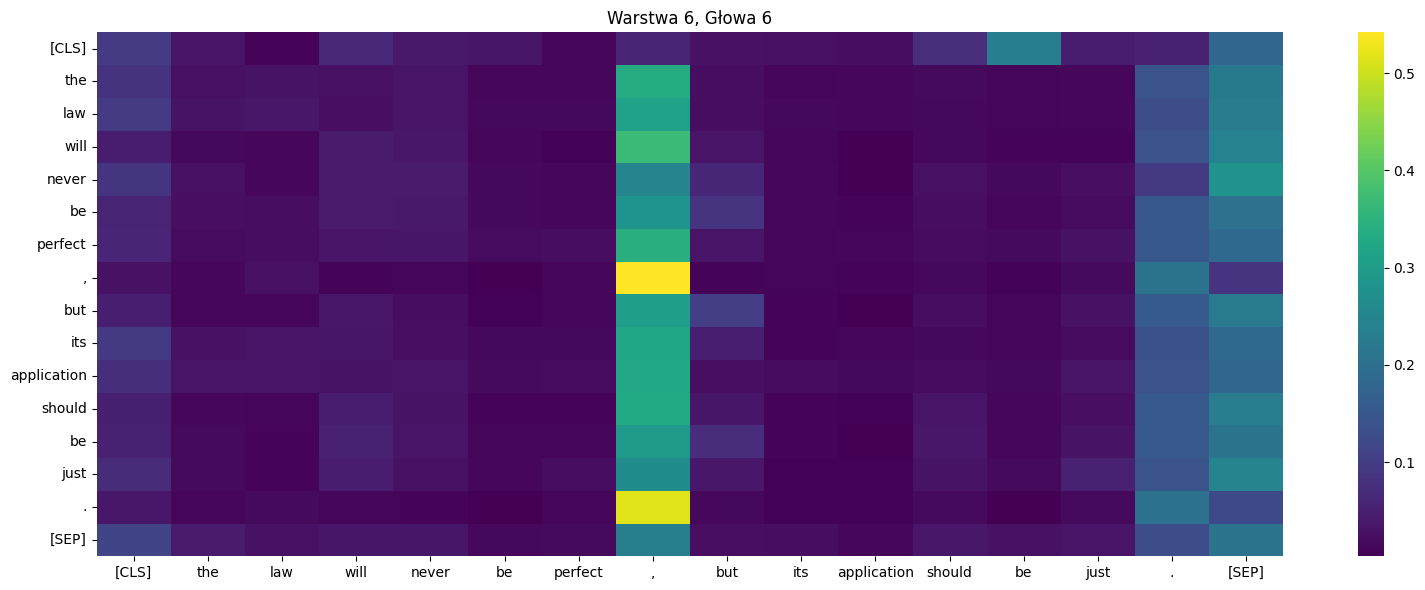

In [15]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification


print("--- EKSPERYMENT 3: ANALIZA MAP UWAGI (ATTENTION MAPS) ---")

# 1. Ścieżka do modelu
model_path = "distilbert-base-uncased" 

# 2. Ładowanie modelu i tokenizatora
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Wymuszamy zwrócenie map uwagi (attention maps) podczas ładowania modelu
model = AutoModelForSequenceClassification.from_pretrained(
    model_path, 
    output_attentions=True 
)

# 3. Definicja tekstu do analizy
# Używamy klasycznego zdania z artykułu "Attention Is All You Need", 
# aby sprawdzić, czy model połączy "its" z "Law".
text = "The Law will never be perfect, but its application should be just."

# Tokenizacja wejścia
inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)

# Wybieramy pierwszy element z batcha i zamieniamy na listę
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())

# 4. Uruchomienie predykcji bez liczenia gradientów (Inference)
with torch.no_grad():
    outputs = model(**inputs)
    
# Pobranie przewidzianej klasy i wag uwagi
logits = outputs.logits
predicted_class = torch.argmax(logits, dim=-1).item()
print(f"Predykcja modelu (Klasa): {predicted_class}")

# outputs.attentions to krotka (tuple) zawierająca mapy dla każdej warstwy
# Kształt pojedynczej mapy: [batch_size, num_heads, sequence_length, sequence_length]
attentions = outputs.attentions

# 5. Wizualizacja dla wybranej warstwy i głowy (np. ostatnia warstwa)
# Wybieramy ostatnią warstwę (-1)
layer_to_visualize = -1 
last_layer_attention = attentions[layer_to_visualize].squeeze(0) # Pozbywamy się wymiaru batch

num_heads = last_layer_attention.size(0)
print(f"Liczba głów (heads) w analizowanej warstwie: {num_heads}")

# Wybieramy konkretną głowę do analizy (np. głowę nr 0 i nr 5)
heads_to_plot = [6] 

fig, axes = plt.subplots(1, len(heads_to_plot), figsize=(16, 6))

if len(heads_to_plot) == 1:
    axes = [axes]

for idx, head_idx in enumerate(heads_to_plot):
    # Pobieramy macierz NxN dla konkretnej głowy
    attention_matrix = last_layer_attention[head_idx].numpy()
    
    # Rysowanie heatmapy za pomocą Seaborn
    sns.heatmap(
        attention_matrix, 
        xticklabels=tokens, 
        yticklabels=tokens, 
        cmap="viridis", 
        ax=axes[idx], # Teraz to działa zawsze
        cbar=True
    )
    axes[idx].set_title(f"Warstwa {len(attentions)}, Głowa {head_idx}")

plt.tight_layout()
plt.show()

* Analizowana głowa (6,6) uwagi skupia się wyłącznie na znakach interpunkcyjnych. Zamiast łączyć znaczenia poszczególnych słów, używa ona interpunkcji do wyznaczania granic poszczególnych zdań składowych.

In [ ]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification

def analyze_and_plot_attention(text, model, tokenizer, layer_to_visualize=-1, heads_to_plot=None):
    """
    Funkcja generująca heatmapy uwagi dla podanego tekstu.
    
    Parametry:
    - text: Zdanie do analizy
    - model: Załadowany model Hugging Face (musi mieć output_attentions=True)
    - tokenizer: Załadowany tokenizator
    - layer_to_visualize: Indeks warstwy do analizy (domyślnie -1, czyli ostatnia)
    - heads_to_plot: Lista indeksów głów do narysowania (domyślnie [6])
    """
    if heads_to_plot is None:
        heads_to_plot = [6]
        
    print(f"\n{'-'*60}")
    print(f"Analiza tekstu: '{text}'")
    print(f"{'-'*60}")
    
    # 1. Tokenizacja wejścia
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=64)
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())

    # 2. Uruchomienie predykcji bez liczenia gradientów
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Pobranie przewidzianej klasy
    logits = outputs.logits
    predicted_class = torch.argmax(logits, dim=-1).item()
    print(f"Predykcja modelu (Klasa): {predicted_class}")

    # Pobranie map uwagi dla konkretnej warstwy
    attentions = outputs.attentions
    last_layer_attention = attentions[layer_to_visualize].squeeze(0)

    # 3. Rysowanie wykresów
    # Dynamicznie dostosowujemy szerokość wykresu w zależności od liczby badanych głów
    fig, axes = plt.subplots(1, len(heads_to_plot), figsize=(8 * len(heads_to_plot), 6))
    
    # Upewniamy się, że axes to lista (zabezpieczenie przed błędem z poprzedniego kroku)
    if len(heads_to_plot) == 1:
        axes = [axes]

    for idx, head_idx in enumerate(heads_to_plot):
        attention_matrix = last_layer_attention[head_idx].numpy()
        
        sns.heatmap(
            attention_matrix, 
            xticklabels=tokens, 
            yticklabels=tokens, 
            cmap="viridis", 
            ax=axes[idx],
            cbar=True
        )
        
        # Prawidłowe oznaczanie numeru warstwy w tytule
        layer_num = len(attentions) if layer_to_visualize == -1 else layer_to_visualize
        axes[idx].set_title(f"Warstwa {layer_num}, Głowa {head_idx}")
        axes[idx].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

# =====================================================================
# GŁÓWNA CZĘŚĆ SKRYPTU - Ładowanie modelu i pętla testowa
# =====================================================================

print("--- EKSPERYMENT 3: ANALIZA MAP UWAGI (FUNKCJA) ---")

model_path = "distilbert-base-uncased"

# Ładujemy tylko raz!
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(
    model_path, 
    output_attentions=True
)

# Baza zdań do analizy mechanizmu uwagi
test_sentences = [
    # 1. Klasyk: Wiązanie zaimków (Czy "its" łączy się z "Law"?)
    "The Law will never be perfect, but its application should be just.",
    
    # 2. Schemat Winograda: O czym mówi "it"? (O zwierzęciu, nie o ulicy, bo jest zmęczone)
    "The animal didn't cross the street because it was too tired.",
    
    # 3. Wieloznaczność (Polysemy): Słowo "bank" jako brzeg rzeki...
    "The bank of the river was full of dead trees.",
    
    # 4. ...oraz słowo "bank" jako instytucja finansowa. Model powinien zwracać uwagę na inny kontekst.
    "I deposited all my money in the local bank.",
    
    # 5. Zaprzeczenie i sentyment: Jak model radzi sobie ze słowem "not" obok "terrible"?
    "The movie was not terrible, in fact it was quite brilliant."
]

--- EKSPERYMENT 3: ANALIZA MAP UWAGI (FUNKCJA) ---


The following layers were not sharded: distilbert.transformer.layer.*.output_layer_norm.bias, distilbert.transformer.layer.*.ffn.lin1.weight, distilbert.transformer.layer.*.attention.out_lin.bias, distilbert.transformer.layer.*.ffn.lin1.bias, pre_classifier.weight, distilbert.transformer.layer.*.attention.k_lin.weight, classifier.bias, distilbert.transformer.layer.*.output_layer_norm.weight, distilbert.transformer.layer.*.sa_layer_norm.bias, distilbert.transformer.layer.*.attention.v_lin.weight, distilbert.transformer.layer.*.attention.out_lin.weight, distilbert.transformer.layer.*.attention.q_lin.weight, distilbert.embeddings.word_embeddings.weight, pre_classifier.bias, distilbert.embeddings.position_embeddings.weight, distilbert.transformer.layer.*.attention.k_lin.bias, distilbert.transformer.layer.*.ffn.lin2.weight, distilbert.embeddings.LayerNorm.weight, distilbert.transformer.layer.*.ffn.lin2.bias, distilbert.embeddings.LayerNorm.bias, distilbert.transformer.layer.*.sa_layer_norm.


------------------------------------------------------------
Analiza tekstu: 'The Law will never be perfect, but its application should be just.'
------------------------------------------------------------
Predykcja modelu (Klasa): 1


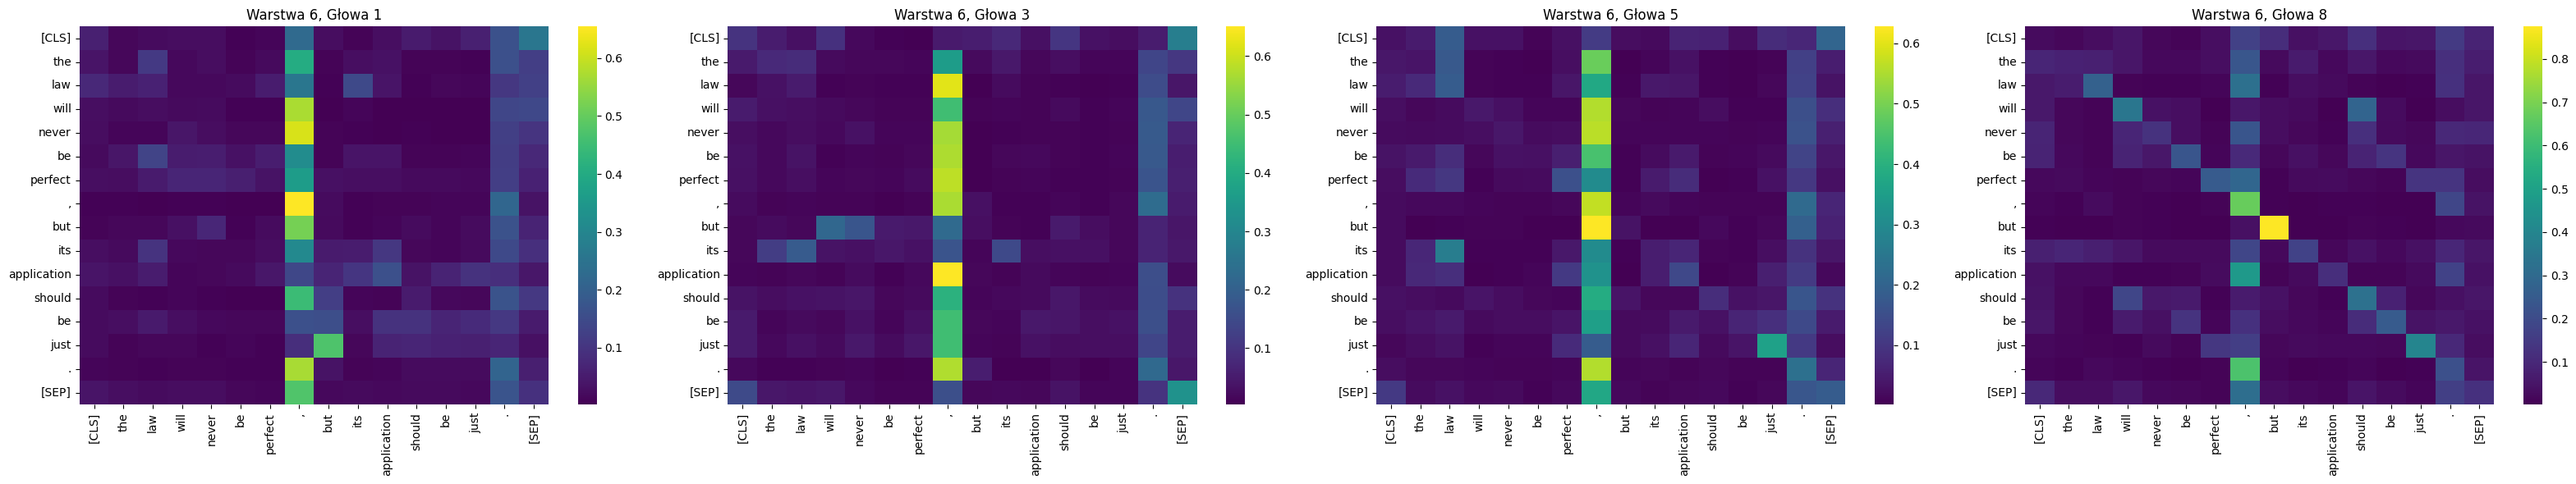

In [23]:
# Uruchamiamy funkcję dla każdego zdania w pętli
# Badamy głowę nr 0 i nr 6 na ostatniej warstwieb
analyze_and_plot_attention(
        text=test_sentences[0], 
        model=model, 
        tokenizer=tokenizer, 
        layer_to_visualize=-1, 
        heads_to_plot=[1,3,5,8] 
)

* Głowy (1,3,5) skupiają się głównie na interpunkcji na przecinku, widzimy to poprzez pionowy pas wysokiej aktywacji na środku mapy uwagi.
* Głowa 8 ma strukturę lekko diagonalną, co może oznaczać to, że pilnuje kolejności słów, natomiast możemy dostrzec również, że skupia swoją uwagę na słowie `but`, które zmienia kontekst zdania.


------------------------------------------------------------
Analiza tekstu: 'The animal didn't cross the street because it was too tired.'
------------------------------------------------------------
Predykcja modelu (Klasa): 1


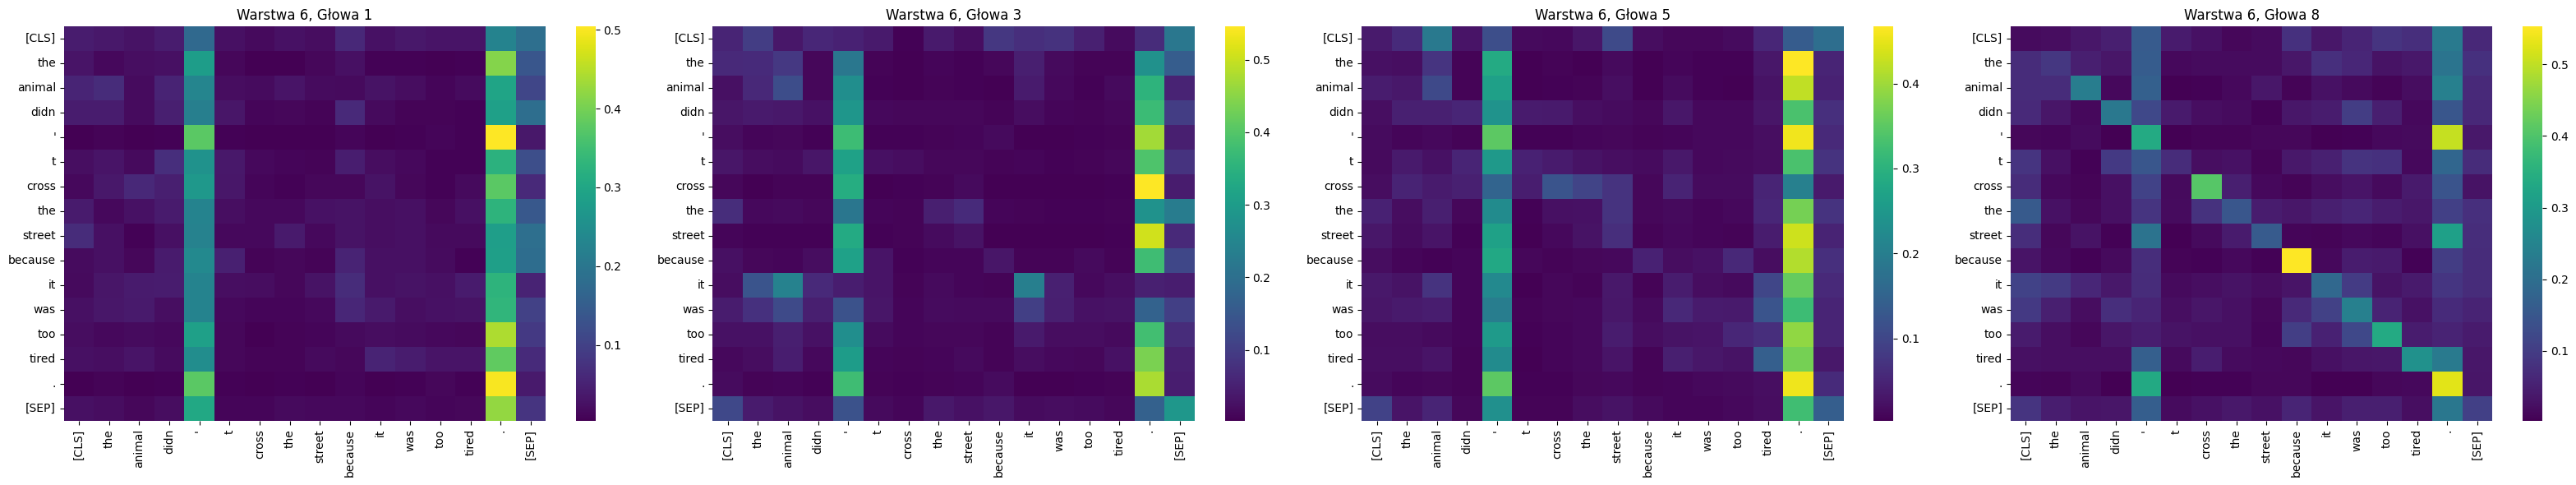

In [27]:
analyze_and_plot_attention(
        text=test_sentences[1], 
        model=model, 
        tokenizer=tokenizer, 
        layer_to_visualize=-1, 
        heads_to_plot=[1,3,5,8] 
    )

* Na warstwie 6, głowie 3 możemy zauwazyć, że poza skupieniem modelu na znaku `'` oraz `.` model połączył poprawnie słowo `animal` z `the`, co wskazuje, że zrozumiał kontekst zdania.
* Ponownie na głowie numer 8 widzimy diagonalną strukturę. Tokeny zwracają uwagę na słowa znajdujące się obok siebie.


------------------------------------------------------------
Analiza tekstu: 'The bank of the river was full of dead trees.'
------------------------------------------------------------
Predykcja modelu (Klasa): 1


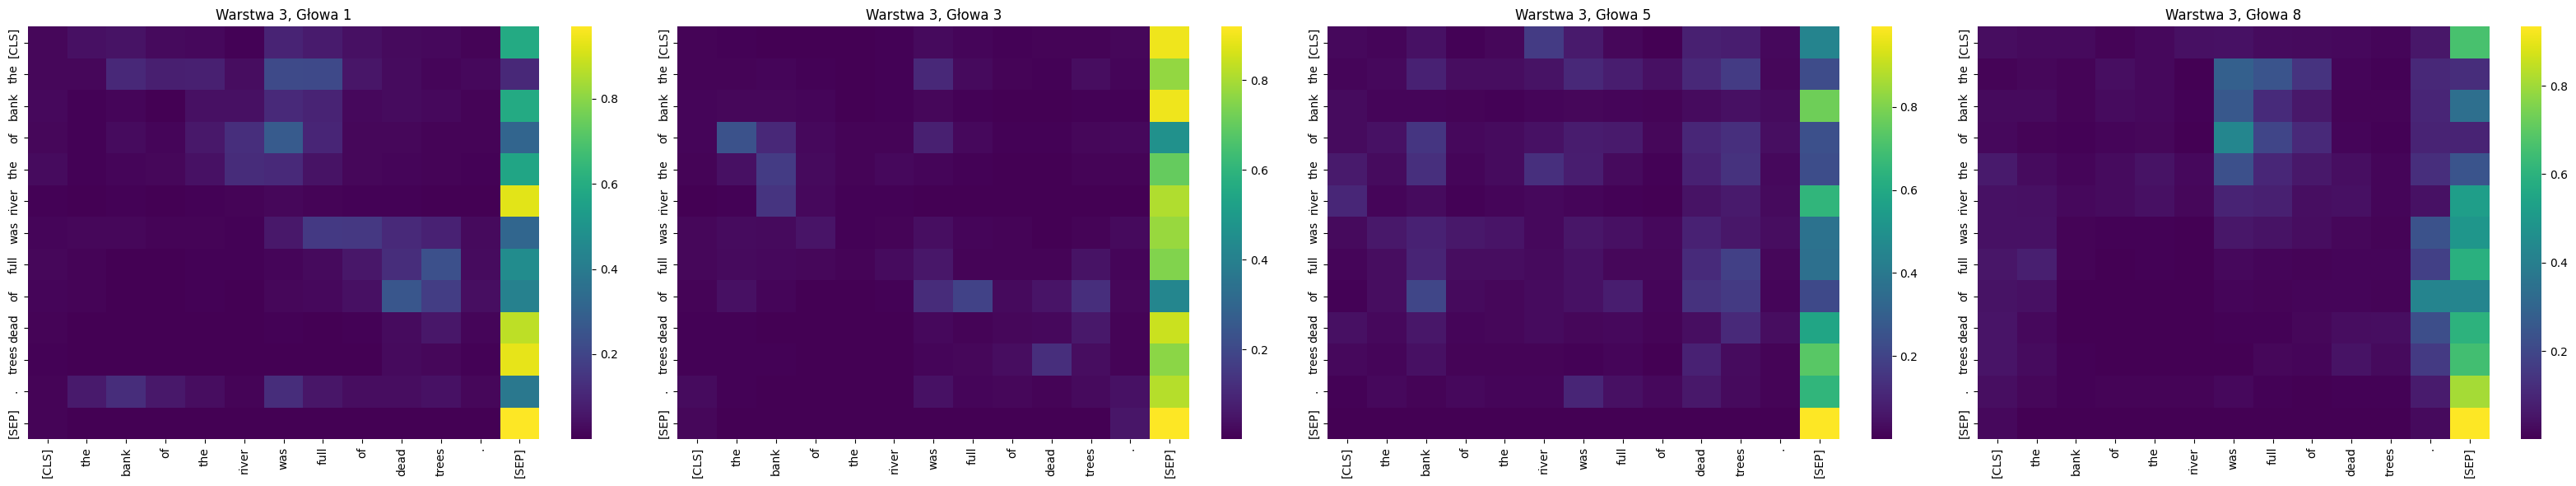

In [28]:
analyze_and_plot_attention(
        text=test_sentences[2], 
        model=model, 
        tokenizer=tokenizer, 
        layer_to_visualize=3, 
        heads_to_plot=[1,3,5,8] 
    )

* Poza znakiem końcowym, model niewiele tutaj wyłapuje kontekstu, delikatnie możemy coś zauważyć, że próbuje łączyć słowo `was` z `of`


------------------------------------------------------------
Analiza tekstu: 'I deposited all my money in the local bank.'
------------------------------------------------------------
Predykcja modelu (Klasa): 1


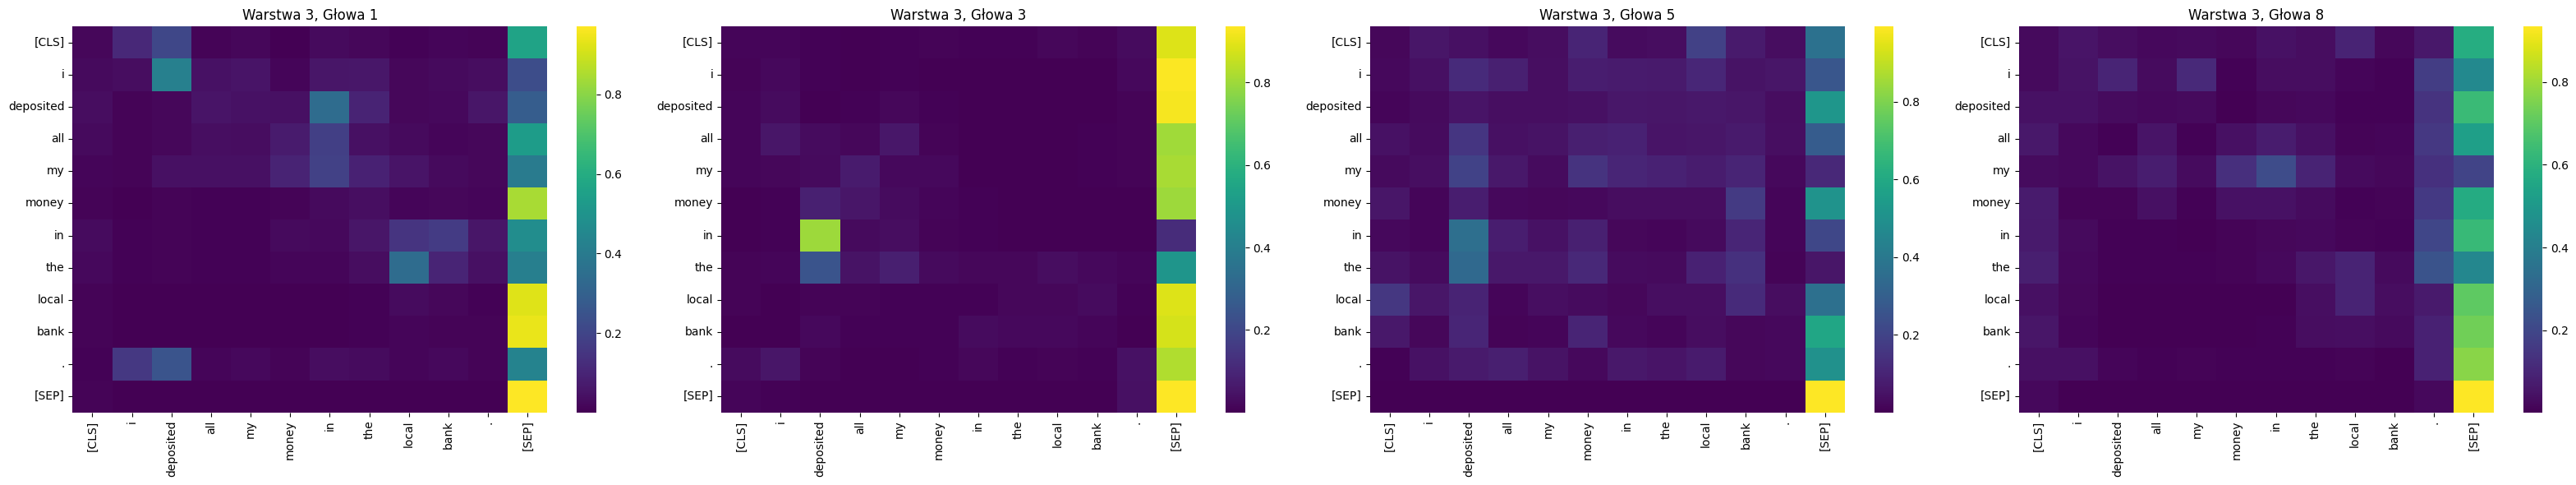

In [21]:
analyze_and_plot_attention(
        text=test_sentences[3], 
        model=model, 
        tokenizer=tokenizer, 
        layer_to_visualize=3, 
        heads_to_plot=[1,3,5,8] 
    )

* Poza znakiem końcowym możemy zauważyć, że model wyłapuje lekką korelację słów `I` z `deposited` oraz zdecydowanie silniejszą `deposited` z `in`.


------------------------------------------------------------
Analiza tekstu: 'The movie was not terrible, in fact it was quite brilliant.'
------------------------------------------------------------
Predykcja modelu (Klasa): 1


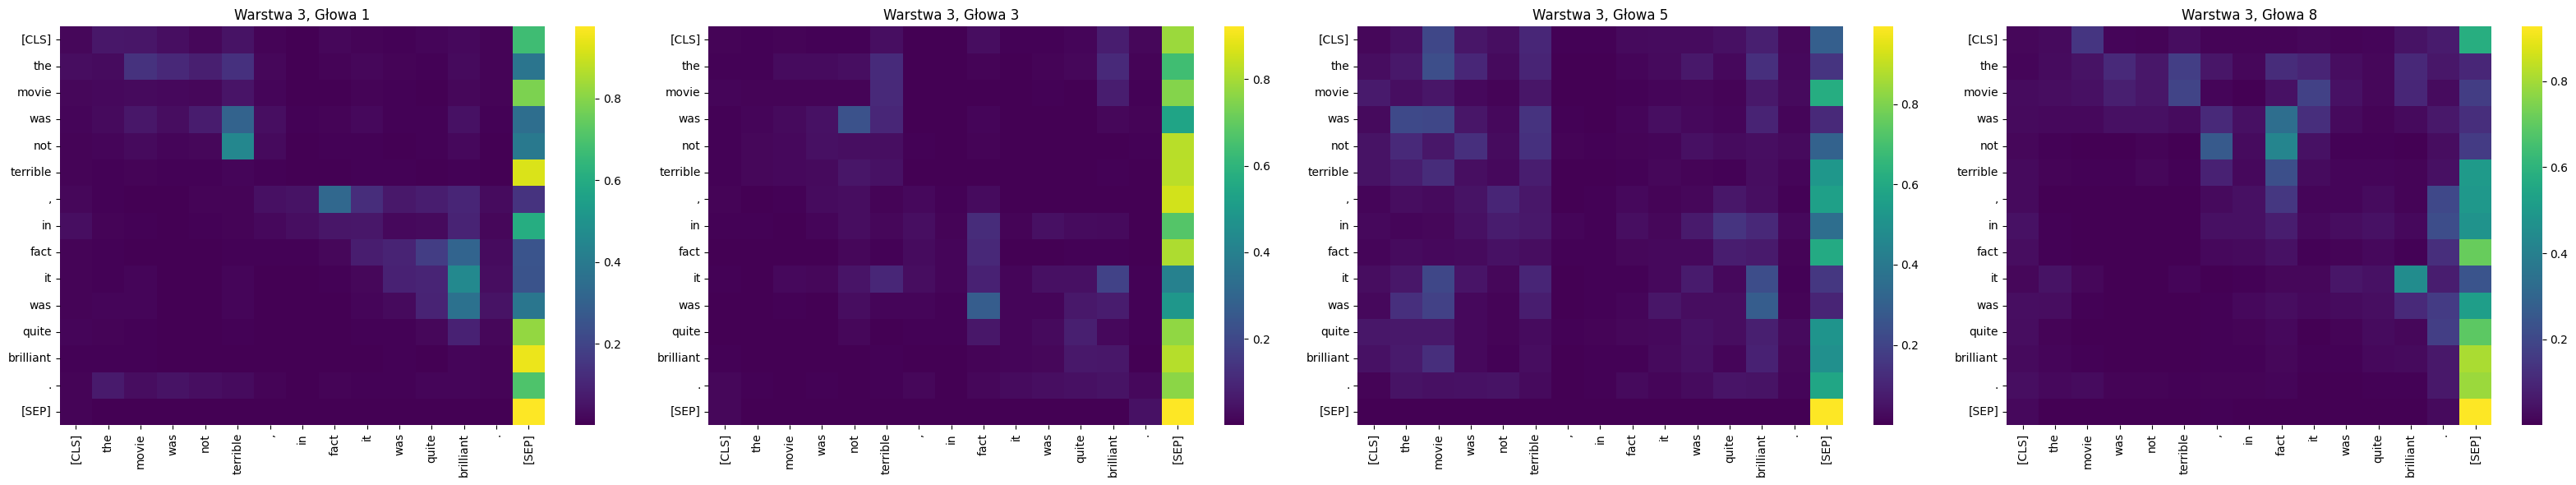

In [22]:
analyze_and_plot_attention(
        text=test_sentences[4], 
        model=model, 
        tokenizer=tokenizer, 
        layer_to_visualize=3, 
        heads_to_plot=[1,3,5,8] 
    )

* Już w pierwszej głowie model złapał kontekst i połączył słowa `not` z `terrible` oraz `brilliant` z `it`, `was`
* W głowie 8 model połączyć `brilliant` z `it`, czyli zrozumiał kontekst słów, które nie stały obok siebie